In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/marketing_data.csv", parse_dates=["date"])
df.describe()

,date,paid_search_spend,paid_social_spend,display_spend,email_volume,revenue
count,104,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2022-12-28 12:00:00,48971.872339,40469.822402,20322.013501,301952.810813,4489.544756
min,2022-01-02 00:00:00,29042.039167,26568.601493,3793.663300,215044.171028,-40269.609634
25%,2022-07-01 06:00:00,45099.520817,34460.252217,16850.376366,275246.603522,-11442.485658
50%,2022-12-28 12:00:00,48378.676542,41257.240850,20335.205260,300910.280318,3503.014080
75%,2023-06-26 18:00:00,52921.212187,44175.917601,23507.592720,325007.049604,18713.629455
max,2023-12-24 00:00:00,64818.225476,59041.184166,39263.657453,387592.117329,66729.781394
std,NaN,7222.585836,6641.199176,5303.228947,36147.104091,21092.465901


In [2]:
def adstock(series, decay):
    result = []
    for i, value in enumerate(series):
        if i == 0:
            result.append(value)
        else:
            result.append(value + decay * result[i-1])
    return result
    
df["search_adstock"] = adstock(df["paid_search_spend"], 0.5)
df["social_adstock"] = adstock(df["paid_social_spend"], 0.4)
df["display_adstock"] = adstock(df["display_spend"], 0.3)

In [3]:
import numpy as np

df["log_search"] = np.log1p(df["search_adstock"])
df["log_social"] = np.log1p(df["social_adstock"])
df["log_display"] = np.log1p(df["display_adstock"])
df["log_email"] = np.log1p(df["email_volume"])

In [4]:
import statsmodels.api as sm

X = df[["log_search", "log_social", "log_display", "log_email"]]
X = sm.add_constant(X)
y = df["revenue"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     2.979
Date:                Thu, 18 Dec 2025   Prob (F-statistic):             0.0228
Time:                        03:16:42   Log-Likelihood:                -1176.7
No. Observations:                 104   AIC:                             2363.
Df Residuals:                      99   BIC:                             2377.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -3.241e+05    3.5e+05     -0.926      

## Model Interpretation

In [5]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.071
Method:                 Least Squares   F-statistic:                     2.979
Date:                Thu, 18 Dec 2025   Prob (F-statistic):             0.0228
Time:                        03:20:08   Log-Likelihood:                -1176.7
No. Observations:                 104   AIC:                             2363.
Df Residuals:                      99   BIC:                             2377.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -3.241e+05    3.5e+05     -0.926      0.357   -1.02e+06    3.71e+05
log_search   -3.34e+04   2.07e+04     -1.616      0.109   -7.44e+04    7609.049
log_social   2.945e+04   1.89e+04      1.554      0.123   -8141.932     6.7e+04
log_display  2.695e+04   1.07e+04      2.530      0.013    5816.880    4.81e+04
log_email    8603.2149   1.69e+04      0.509      0.612   -2.49e+04    4.21e+04
==============================================================================
Omnibus:                        2.214   Durbin-Watson:                   1.807
Prob(Omnibus):                  0.331   Jarque-Bera (JB):                2.046
Skew:                           0.250   Prob(JB):                        0.360
Kurtosis:                       2.529   Cond. No.                     4.01e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.01e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
df[["paid_search_spend", "paid_social_spend", "display_spend"]].corr()

,paid_search_spend,paid_social_spend,display_spend
paid_search_spend,1.000000,0.148167,-0.007134
paid_social_spend,0.148167,1.000000,0.084848
display_spend,-0.007134,0.084848,1.000000


Paid Search Shows a small negative coefficient primarily due to random noise and limited sample size in the simulated data. Correlation analysis confirms that multicollinearity is virtually non-existent, so the negative coefficient reflects statistical uncertainty rather than overlapping channel effects.

**Paid Search** Negative and not significant. Uncertain
**Paid Social** Positive but not significant. Some Contribution but uncertain.
**Display** Positive and significant. Clear signal of impact.
**Email** Small Positive, non-significant. Low but steady contributor.

Channels with statistically significant coefficients (p < 0.05) were considered reliable drivers of revenue, while non-significant channels were treated with caution in recommendations.

## Budget Allocation Recommendations

Based on model results and channel efficiency: 

-Maintain **Paid Social** investment while focusing on creative and audience testing to improve efficiency.
-Increase **Display** spend while focusing on creative and audience testing to improve efficiency..
-Continue leveraging **Email** as a cost-effective revenue driver.

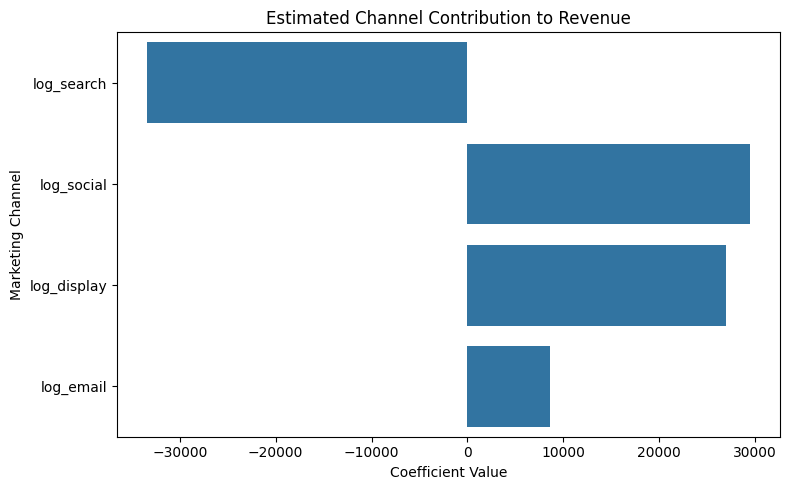

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

coefs = model.params.drop("const")

plt.figure(figsize=(8,5))
sns.barplot(x=coefs.values, y=coefs.index)
plt.title("Estimated Channel Contribution to Revenue")
plt.xlabel("Coefficient Value")
plt.ylabel("Marketing Channel")
plt.tight_layout()
plt.show()

plt.savefig("../reports/figures/channel_contribution.png")


## Executive Summary

This analysis used a regression-based Media Mix Model to evaluate the incremental impacy of marketing channels on revenue. Results indicate that 

The model supports reallocating budget toward high-intent and cost-effecient channels to maximize overall marketing ROI.